# EV Charging Infrastructure Planning & Demand Prediction

## Notebook 07 : Exploratory Data Analysis

### Business Objective

The objective of this notebook is to understand EV adoption trends, charging infrastructure, customer demand, station utilization, waiting time, and business performance through exploratory data analysis. The insights generated in this notebook will support feature engineering and machine learning model development.

In [24]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [25]:
master = pd.read_csv("../data/processed/master_dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [26]:
print("Shape :", master.shape)

master.head()

Shape : (9955, 56)


,Year,State,City,Population,Month,Month_No,2W,3W,4W,Bus,Goods,Total_EV,Public_AC,Public_DC,Private,Highway_Fast,Total_Charging_Stations,Station_Utilization,Avg_Daily_Sessions,Station_ID,Station_Name,Latitude,Longitude,Station_Type,Operator,Charger_Type,Total_Chargers,AC_Chargers,DC_Chargers,Fast_Chargers,Installation_Year,Parking_Capacity,Nearby_Highway,Nearby_Mall,Nearby_Hospital,Nearby_EV_Population,Status,Fast_Charger_Ratio,DC_Ratio,Station_Age,Utilization_Level,Avg_Daily_Users,Peak_Hour_Users,Avg_Wait_Time_Min,Avg_Charging_Time_Min,Queue_Length,Energy_Delivered_kWh,Usage_Utilization,Fault_Count,Downtime_Hours,Revenue_INR,Customer_Rating,Sessions,Completed_Sessions,Cancelled_Sessions,Demand_Level
0,2021,Andhra Pradesh,Visakhapatnam,2287676,January,1.0,961.0,180.0,135.0,12.0,54.0,1342.0,12.0,4.0,7.0,2.0,25.0,57.9,189.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021,Andhra Pradesh,Visakhapatnam,2287676,February,2.0,1115.0,209.0,156.0,13.0,62.0,1555.0,12.0,4.0,7.0,2.0,25.0,57.9,189.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,Andhra Pradesh,Visakhapatnam,2287676,March,3.0,1142.0,214.0,160.0,14.0,64.0,1594.0,12.0,4.0,7.0,2.0,25.0,57.9,189.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,Andhra Pradesh,Visakhapatnam,2287676,April,4.0,1131.0,212.0,159.0,14.0,63.0,1579.0,12.0,4.0,7.0,2.0,25.0,57.9,189.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021,Andhra Pradesh,Visakhapatnam,2287676,May,5.0,1093.0,205.0,153.0,13.0,61.0,1525.0,12.0,4.0,7.0,2.0,25.0,57.9,189.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
print(master.info())

<class 'pandas.DataFrame'>
RangeIndex: 9955 entries, 0 to 9954
Data columns (total 56 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     9955 non-null   int64  
 1   State                    9955 non-null   str    
 2   City                     9955 non-null   str    
 3   Population               9955 non-null   int64  
 4   Month                    9720 non-null   str    
 5   Month_No                 9720 non-null   float64
 6   2W                       9720 non-null   float64
 7   3W                       9720 non-null   float64
 8   4W                       9720 non-null   float64
 9   Bus                      9720 non-null   float64
 10  Goods                    9720 non-null   float64
 11  Total_EV                 9720 non-null   float64
 12  Public_AC                8600 non-null   float64
 13  Public_DC                8600 non-null   float64
 14  Private                  8600 non-n

In [28]:
print(master.describe())

              Year    Population    Month_No           2W           3W  \
count  9955.000000  9.955000e+03  9720.00000  9720.000000  9720.000000   
mean   2023.000000  2.083609e+06     6.50000  2176.200514   407.635288   
std       1.414285  2.472404e+06     3.45223   895.721493   167.952429   
min    2021.000000  1.417900e+05     1.00000   835.000000   156.000000   
25%    2022.000000  8.393680e+05     3.75000  1506.000000   282.000000   
50%    2023.000000  1.182547e+06     6.50000  1995.000000   374.000000   
75%    2024.000000  1.699810e+06     9.25000  2644.250000   495.000000   
max    2025.000000  1.298986e+07    12.00000  5494.000000  1030.000000   

                4W          Bus        Goods     Total_EV    Public_AC  \
count  9720.000000  9720.000000  9720.000000  9720.000000  8600.000000   
mean    305.598663    26.703292   121.945988  3038.083745    81.350814   
std     125.963722    11.198204    50.388652  1251.219516    61.594805   
min     117.000000    10.000000    46

In [29]:
print(master.isnull().sum())

Year                          0
State                         0
City                          0
Population                    0
Month                       235
Month_No                    235
2W                          235
3W                          235
4W                          235
Bus                         235
Goods                       235
Total_EV                    235
Public_AC                  1355
Public_DC                  1355
Private                    1355
Highway_Fast               1355
Total_Charging_Stations    1355
Station_Utilization        1355
Avg_Daily_Sessions         1355
Station_ID                 2615
Station_Name               2615
Latitude                   2615
Longitude                  2615
Station_Type               2615
Operator                   2615
Charger_Type               2615
Total_Chargers             2615
AC_Chargers                2615
DC_Chargers                2615
Fast_Chargers              2615
Installation_Year          2615
Parking_

In [30]:
print("Duplicate Rows :", master.duplicated().sum())

Duplicate Rows : 0


In [31]:
population_eda = (
    master[
        ["State", "City", "Population"]
    ]
    .drop_duplicates()
)

print(population_eda.shape)
population_eda.head()

(580, 3)


,State,City,Population
0,Andhra Pradesh,Visakhapatnam,2287676
12,Andhra Pradesh,Visakhapatnam,2333266
24,Andhra Pradesh,Visakhapatnam,2352324
36,Andhra Pradesh,Visakhapatnam,2401227
48,Andhra Pradesh,Visakhapatnam,2444384


In [32]:
ev_eda = master[
    master["Year"] == 2025
].copy()

print(ev_eda.shape)

(1991, 56)


In [33]:
operations_eda = master.copy()

print(operations_eda.shape)

(9955, 56)


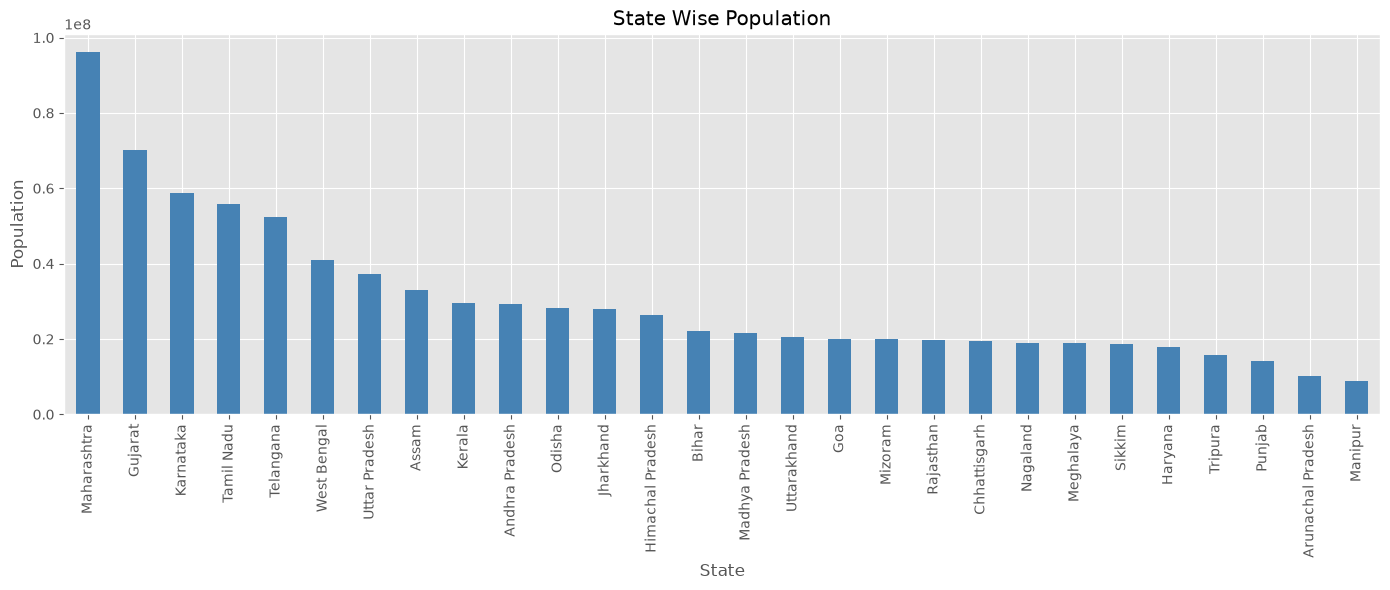

In [34]:
state_population = (
    population_eda
    .groupby("State")["Population"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))

state_population.plot(
    kind="bar",
    color="steelblue"
)

plt.title("State Wise Population")

plt.ylabel("Population")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [35]:
ev_latest = (
    master[
        master["Year"] == 2025
    ][
        ["State", "City", "Month", "Population", "Total_EV"]
    ]
    .drop_duplicates()
)

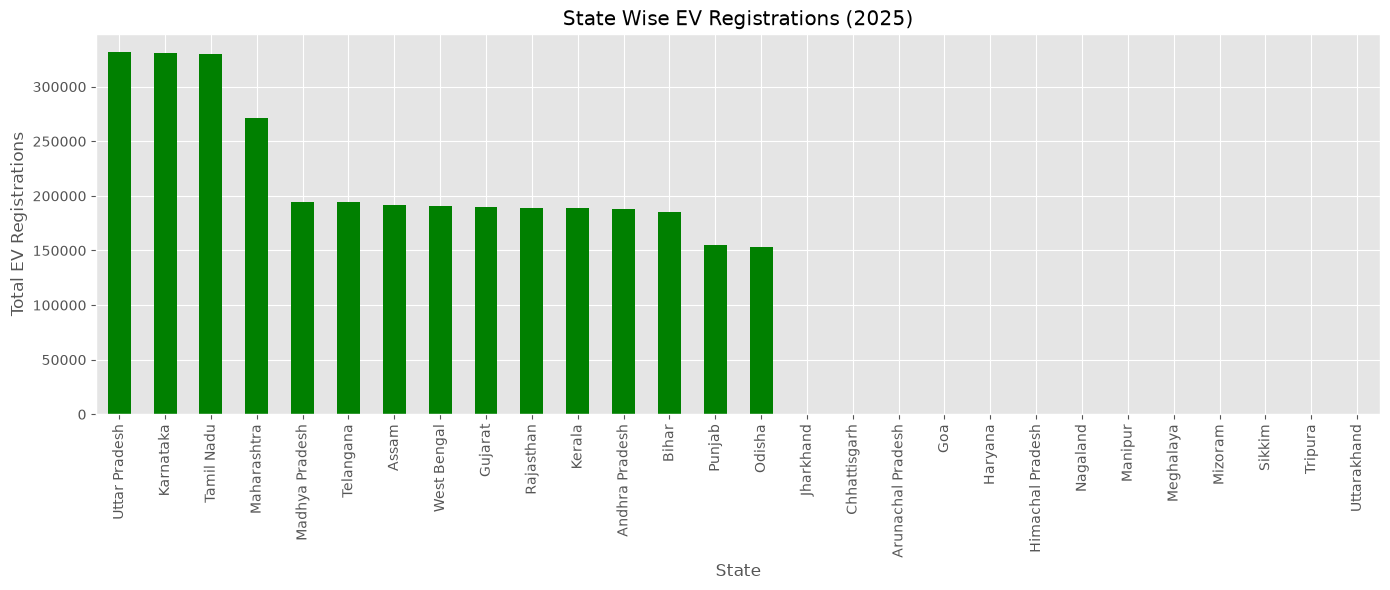

In [36]:
state_ev = (
    ev_latest
    .groupby("State")["Total_EV"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))

state_ev.plot(
    kind="bar",
    color="green"
)

plt.title("State Wise EV Registrations (2025)")

plt.xlabel("State")

plt.ylabel("Total EV Registrations")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

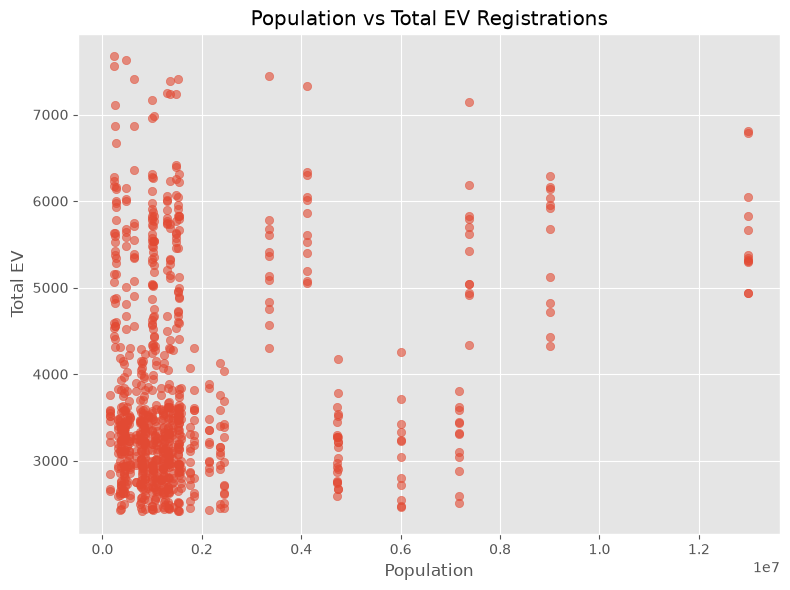

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(
    ev_latest["Population"],
    ev_latest["Total_EV"],
    alpha=0.6
)

plt.title("Population vs Total EV Registrations")

plt.xlabel("Population")

plt.ylabel("Total EV")

plt.grid(True)

plt.tight_layout()

plt.show()

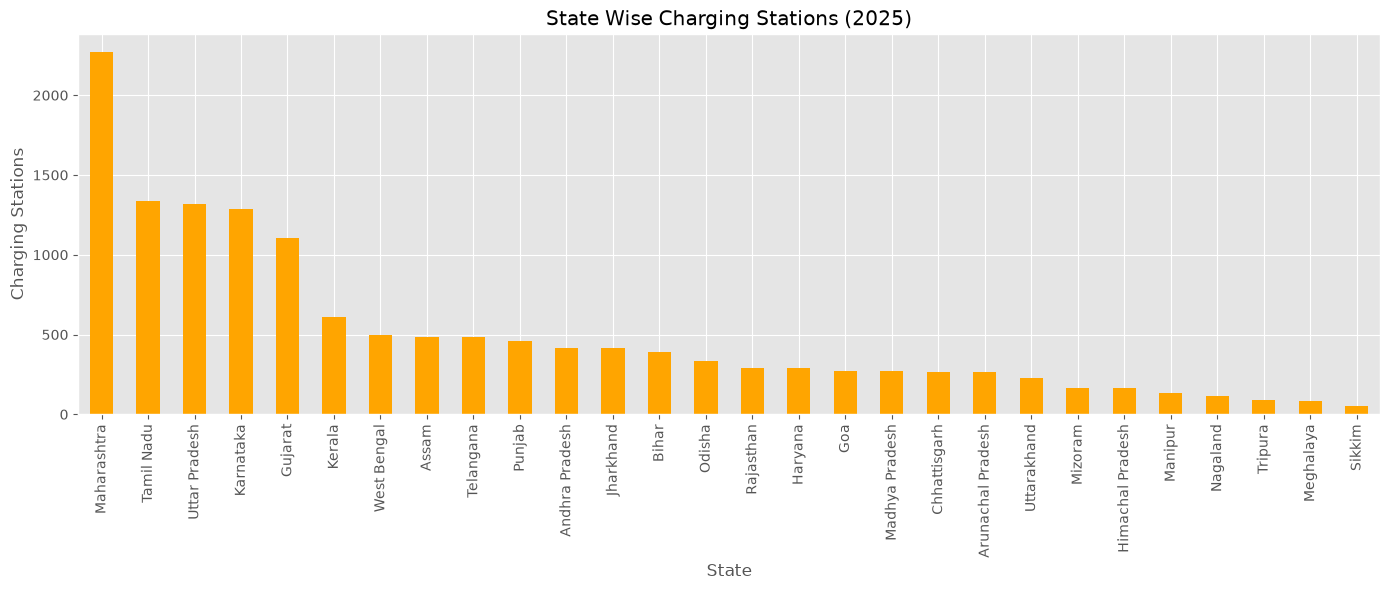

In [38]:
charging_eda = (
    master[
        master["Year"] == 2025
    ][
        [
            "State",
            "City",
            "Total_Charging_Stations"
        ]
    ]
    .drop_duplicates()
)

state_station = (
    charging_eda
    .groupby("State")["Total_Charging_Stations"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))

state_station.plot(
    kind="bar",
    color="orange"
)

plt.title("State Wise Charging Stations (2025)")

plt.xlabel("State")

plt.ylabel("Charging Stations")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

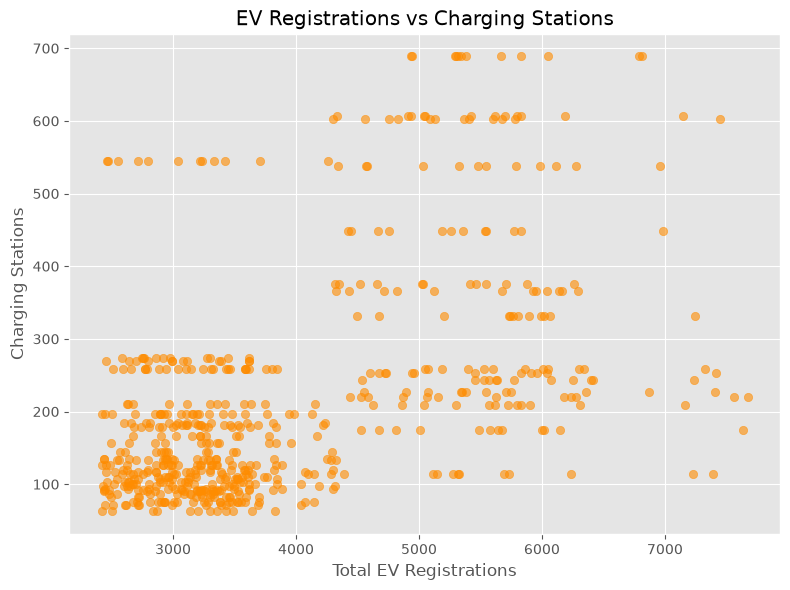

In [39]:
ev_station = (
    master[
        master["Year"] == 2025
    ][
        [
            "Population",
            "Total_EV",
            "Total_Charging_Stations"
        ]
    ]
    .drop_duplicates()
)

plt.figure(figsize=(8,6))

plt.scatter(
    ev_station["Total_EV"],
    ev_station["Total_Charging_Stations"],
    alpha=0.6,
    color="darkorange"
)

plt.title("EV Registrations vs Charging Stations")

plt.xlabel("Total EV Registrations")

plt.ylabel("Charging Stations")

plt.grid(True)

plt.tight_layout()

plt.show()

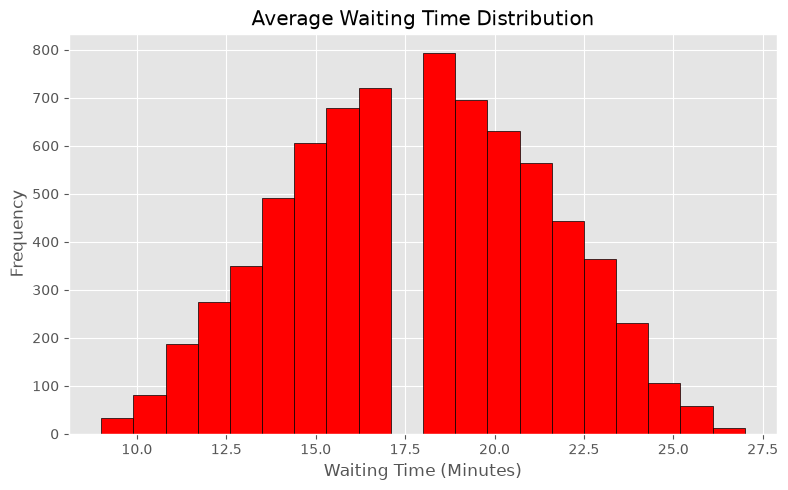

In [40]:
plt.figure(figsize=(8,5))

plt.hist(
    master["Avg_Wait_Time_Min"].dropna(),
    bins=20,
    color="red",
    edgecolor="black"
)

plt.title("Average Waiting Time Distribution")

plt.xlabel("Waiting Time (Minutes)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

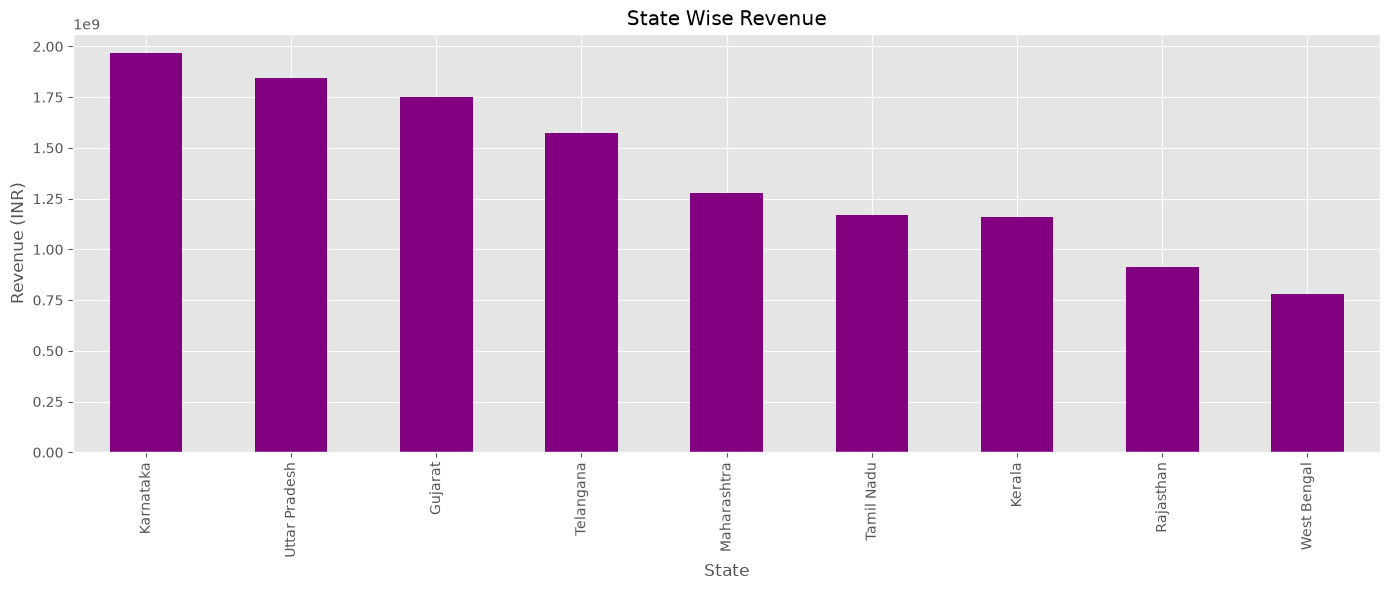

In [41]:
revenue_state = (
    master[
        ["State", "Revenue_INR"]
    ]
    .dropna()
    .groupby("State")["Revenue_INR"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))

revenue_state.plot(
    kind="bar",
    color="purple"
)

plt.title("State Wise Revenue")

plt.xlabel("State")

plt.ylabel("Revenue (INR)")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

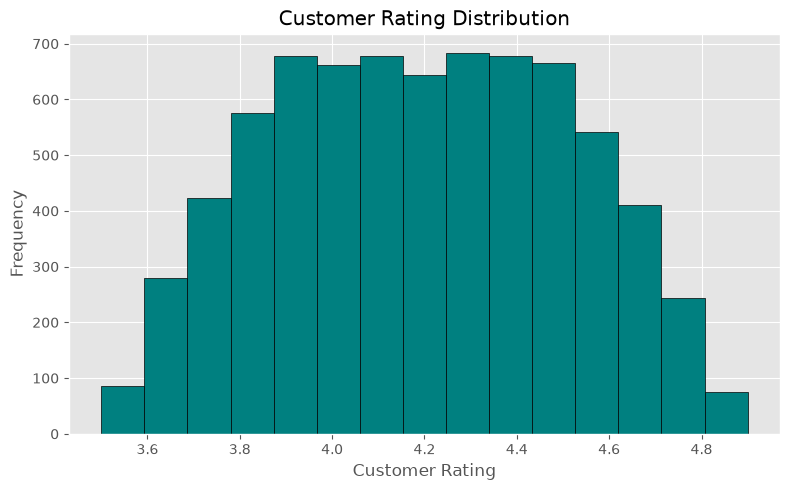

In [42]:
plt.figure(figsize=(8,5))

plt.hist(
    master["Customer_Rating"].dropna(),
    bins=15,
    color="teal",
    edgecolor="black"
)

plt.title("Customer Rating Distribution")

plt.xlabel("Customer Rating")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

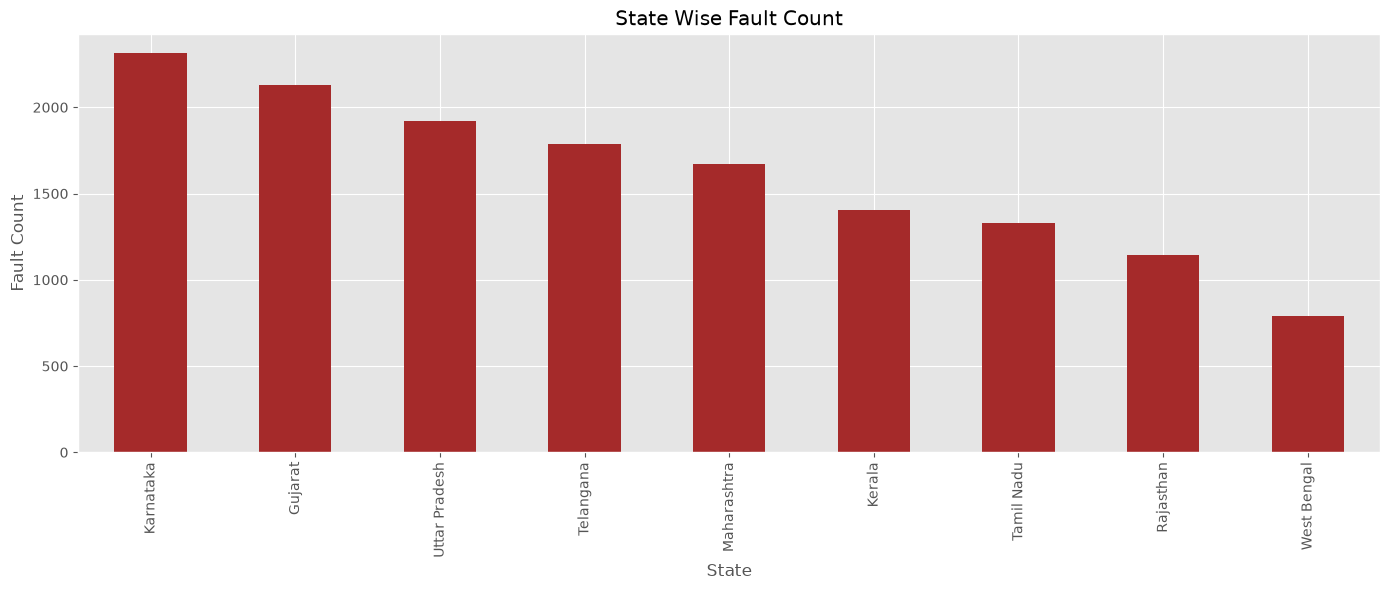

In [43]:
fault_state = (
    master[
        ["State", "Fault_Count"]
    ]
    .dropna()
    .groupby("State")["Fault_Count"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))

fault_state.plot(
    kind="bar",
    color="brown"
)

plt.title("State Wise Fault Count")

plt.xlabel("State")

plt.ylabel("Fault Count")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

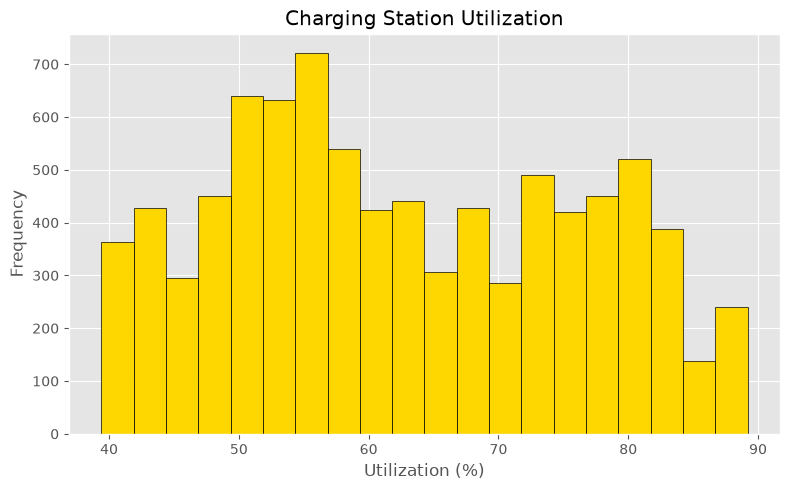

In [44]:
plt.figure(figsize=(8,5))

plt.hist(
    master["Station_Utilization"].dropna(),
    bins=20,
    color="gold",
    edgecolor="black"
)

plt.title("Charging Station Utilization")

plt.xlabel("Utilization (%)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

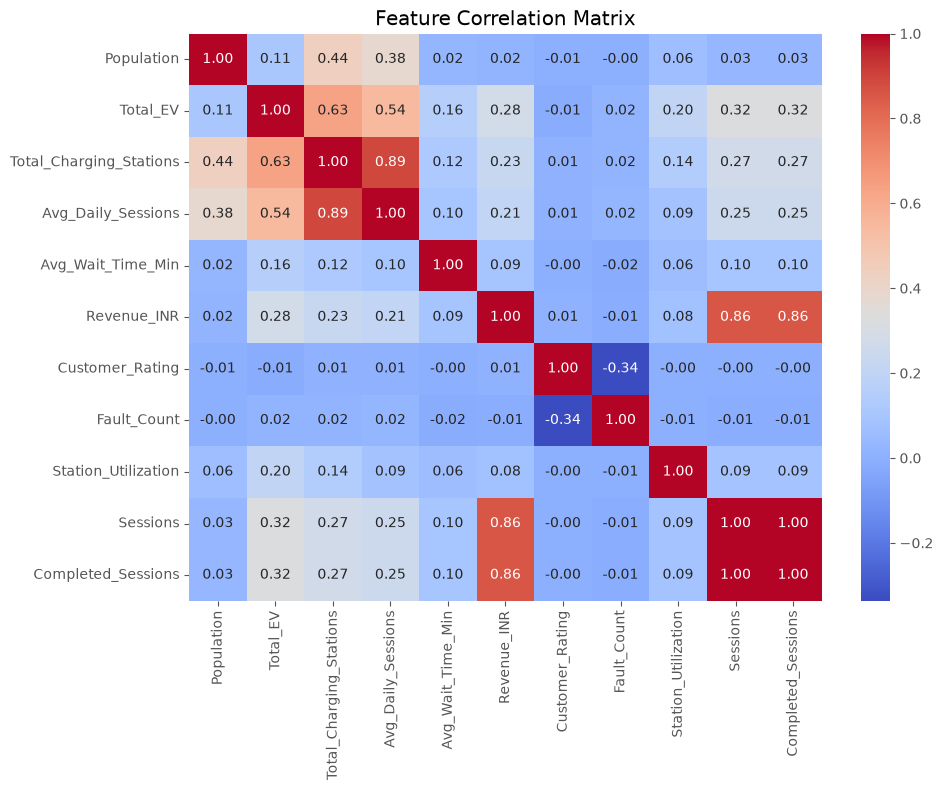

In [45]:
model_features = [
    "Population",
    "Total_EV",
    "Total_Charging_Stations",
    "Avg_Daily_Sessions",
    "Avg_Wait_Time_Min",
    "Revenue_INR",
    "Customer_Rating",
    "Fault_Count",
    "Station_Utilization",
    "Sessions",
    "Completed_Sessions"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    master[model_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.show()

# Business Summary

## Key Findings

- High population cities generally show higher EV adoption.
- States with high EV registrations require additional charging stations.
- Longer waiting times indicate insufficient charging infrastructure.
- Revenue increases with higher charging sessions and utilization.
- Frequent station faults negatively affect customer satisfaction.
- Station utilization is a key indicator for future infrastructure planning.

## Business Recommendations

- Expand charging stations in high EV demand regions.
- Reduce waiting time by increasing charger capacity.
- Improve preventive maintenance to reduce station faults.
- Optimize station placement using EV registration and population trends.
- Focus investments on high-growth cities to maximize revenue and customer satisfaction.